In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import robot_vlp.data_collection.communication as c


%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R




def extract_original_orientation(df):
    """
    Extract the original pitch, yaw, and roll from the vive_data column
    and add them as separate columns to the DataFrame.
    """
    # Extract Vive orientation data
    vive_data = df['vive_data'].apply(lambda v: np.fromstring(v.strip('[]'), sep=' '))
    orientations = np.stack(vive_data.to_list())[:, 3:]  # Extract yaw, pitch, roll
    positions = np.stack(vive_data.to_list())[:, :3]
    
    # Add columns for the original orientation
    df[['yaw', 'pitch', 'roll']] = orientations
    df[['x', 'y', 'z']] = positions
    return df

def transform_positions_to_robot_frame(df):
    """
    Transforms positional data (x, y, z) from the Vive frame to the robot frame.
    """
    # Extract Vive positions
    vive_data = df['vive_data'].apply(lambda v: np.fromstring(v.strip('[]'), sep=' '))
    positions = np.stack(vive_data.to_list())[:, :3]

    # Fit a plane to the Vive positions
    def fit_plane(points):
        centroid = np.mean(points, axis=0)
        centered_points = points - centroid
        _, _, vh = np.linalg.svd(centered_points)
        normal = vh[-1]
        return normal, centroid

    # Fit the plane and compute the rotation matrix
    normal, centroid = fit_plane(positions)
    target_normal = np.array([0, 0, 1])  # Robot's x-y plane (z-aligned)
    rotation_axis = np.cross(normal, target_normal)
    rotation_angle = np.arccos(np.dot(normal, target_normal) / np.linalg.norm(normal))
    plane_alignment_rotation = R.from_rotvec(rotation_axis * rotation_angle).as_matrix()

    # Apply the rotation to align positions
    aligned_positions = (positions - centroid) @ plane_alignment_rotation.T
    aligned_positions -= aligned_positions[0]  # Map the first position to the origin

    # Update the DataFrame with transformed positions
    df[['x', 'y', 'z']] = aligned_positions

    return df

def transform_orientation_with_three_reference_points(df):
    """
    Aligns all Vive points to the robot frame using the derived transform.
    """
    # Instantiate the transformation class
    transformer = c.ViveToRobotTransform()

    # Derive the transformation
    transformer.derive_transform(df)

    # Transform all points in the DataFrame
    vive_positions = df['vive_data'].apply(
        lambda v: np.fromstring(v.strip('[]'), sep=' ')
    )
    transformed_positions = vive_positions.apply(transformer.transform_point)

    # Replace original positions with transformed ones
    df[['x', 'y', 'z']] = np.stack(transformed_positions.to_list())

    return df

def transform_vive_to_robot_frame(df):
    """
    Transform both positional and orientation data from the Vive frame to the robot frame.
    """
    df = extract_original_orientation(df)
    # df = transform_positions_to_robot_frame(df)
    # df = transform_orientation_with_three_reference_points(df)
    return df

#usage
df = pd.read_csv('robot_vive_data_log.csv', delimiter='|', header=0)
df = pd.read_csv('exp_1', delimiter='|', header=0)
df.columns = ['vive_data', 'last_cmd']

# Apply the transformation
df = transform_vive_to_robot_frame(df)




In [3]:
df

,vive_data,last_cmd,yaw,pitch,roll,x,y,z
0,[-1.58853711e-01 -9.26686674e-01 -1.98263496e+...,CAL:1,-179.511074,122.550525,-90.741620,-0.158854,-0.926687,-1.982635
1,[ -0.86348052 -0.91195585 -1.25451654 17...,CAL:2,178.824610,-170.245172,-90.553799,-0.863481,-0.911956,-1.254517
2,[ -0.20843291 -0.93322334 -0.53276771 178.42...,CAL:3,178.429690,168.798111,-92.454206,-0.208433,-0.933223,-0.532768
3,[-3.88309313e-02 1.00020178e-01 4.98039100e-...,MOVE:938.0108722915079,178.898884,-138.348586,-89.622811,-0.038831,0.100020,0.049804
4,[-3.99389796e-02 1.02925663e-01 5.02188948e-...,TURN:312,178.771730,-114.426258,-90.880997,-0.039939,0.102926,0.050219
...,...,...,...,...,...,...,...,...
761,[ 3.04907827e-01 1.07170861e-02 6.79262833e-...,MOVE:938.0108722915079,179.513901,124.028763,-88.368032,0.304908,0.010717,0.067926
762,[ 2.05593556e-01 -1.47067326e-03 6.51906600e-...,MOVE:938.0108722915079,179.764605,123.899964,-88.452024,0.205594,-0.001471,0.065191
763,[ 2.04897124e-01 -1.94175376e-03 6.50914798e-...,TURN:97,-107.976704,131.005470,-88.677349,0.204897,-0.001942,0.065091
764,[ 1.02189265e-01 -2.92105253e-03 6.05021608e-...,MOVE:938.0108722915079,-179.200866,133.181410,-87.949758,0.102189,-0.002921,0.060502


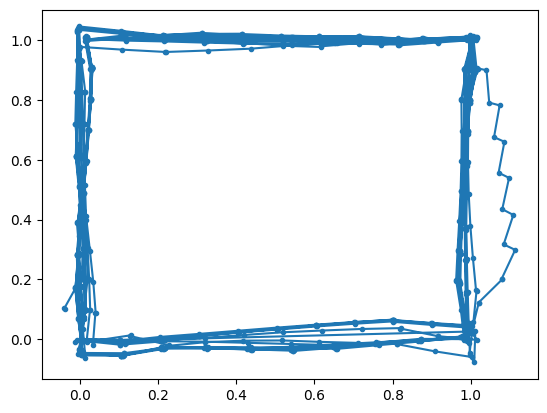

In [4]:
plt.plot(df['x'][3:], df['y'][3:], marker = '.')

# plt.xlim(-2,2)
# plt.ylim(-2,2)

<Axes: >

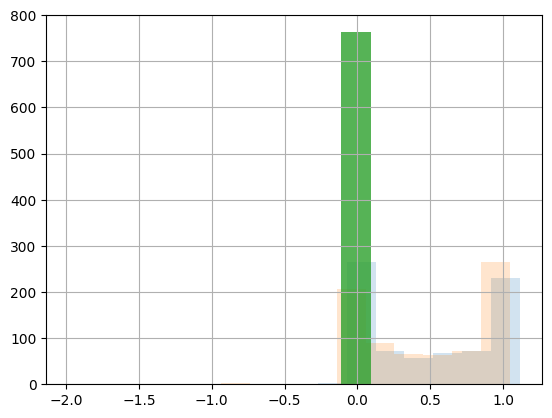

In [5]:

df['x'].hist(alpha = 0.2)
df['y'].hist(alpha = 0.2)
df['z'].hist(alpha = 0.8)


In [6]:
import numpy as np

# Calculate absolute 3D distance traveled
def calculate_distance_2d(df):
    """
    Calculates the 3D distance traveled between consecutive points.
    """
    # Compute differences in x, y, and z between consecutive rows
    df['delta_x'] = df['x'].diff()
    df['delta_y'] = df['y'].diff()
    
    # Compute the Euclidean distance in 3D
    df['distance_traveled'] = np.sqrt(df['delta_x']**2 + df['delta_y']**2 )
    
    # Replace NaN for the first row with 0, since there's no previous point to calculate distance
    df['distance_traveled'].fillna(0, inplace=True)
    
    # Drop intermediate columns if not needed
    df.drop(columns=['delta_x', 'delta_y'], inplace=True)
    
    return df

# Apply the function to your DataFrame
df = calculate_distance_2d(df)

df.head()


/var/folders/j0/3mr_0p157c9d4qgnmrzwc8nm0000gn/T/ipykernel_2286/734583972.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['distance_traveled'].fillna(0, inplace=True)


,vive_data,last_cmd,yaw,pitch,roll,x,y,z,distance_traveled
0,[-1.58853711e-01 -9.26686674e-01 -1.98263496e+...,CAL:1,-179.511074,122.550525,-90.741620,-0.158854,-0.926687,-1.982635,0.000000
1,[ -0.86348052 -0.91195585 -1.25451654 17...,CAL:2,178.824610,-170.245172,-90.553799,-0.863481,-0.911956,-1.254517,0.704781
2,[ -0.20843291 -0.93322334 -0.53276771 178.42...,CAL:3,178.429690,168.798111,-92.454206,-0.208433,-0.933223,-0.532768,0.655393
3,[-3.88309313e-02 1.00020178e-01 4.98039100e-...,MOVE:938.0108722915079,178.898884,-138.348586,-89.622811,-0.038831,0.100020,0.049804,1.047071
4,[-3.99389796e-02 1.02925663e-01 5.02188948e-...,TURN:312,178.771730,-114.426258,-90.880997,-0.039939,0.102926,0.050219,0.003110


In [7]:
# Separate calibration data
calibration_df = df[df["last_cmd"].str.startswith("CAL:")].copy()

# Process 'MOVE' and 'TURN' commands into separate columns
def parse_command(cmd):
    if cmd.startswith("MOVE:"):
        return int(float(cmd.split(":")[1])), 0
    elif cmd.startswith("TURN:"):
        return 0, int(cmd.split(":")[1])
    return 0, 0

df[["move_count", "turn_count"]] = df["last_cmd"].apply(parse_command).apply(pd.Series)

# Drop the calibration rows from the main DataFrame
df = df[~df["last_cmd"].str.startswith("CAL:")].copy()

# df = df[1:100]



In [11]:
move_df

,vive_data,last_cmd,yaw,pitch,roll,x,y,z,distance_traveled,move_count,turn_count,counts_per_cm
3,[-3.88309313e-02 1.00020178e-01 4.98039100e-...,MOVE:938.0108722915079,178.898884,-138.348586,-89.622811,-0.038831,0.100020,0.049804,1.047071,938,0,8.958326
5,[ 2.03657078e-03 2.01821312e-01 5.30848507e-...,MOVE:938.0108722915079,178.301643,-113.587477,-91.312851,0.002037,0.201821,0.053085,0.107435,938,0,87.308541
7,[ 7.32366222e-03 3.04366815e-01 5.32804722e-...,MOVE:938.0108722915079,179.149274,-136.937567,-89.630904,0.007324,0.304367,0.053280,0.103016,938,0,91.053887
8,[ 7.98131253e-03 4.10499360e-01 5.32881976e-...,MOVE:938.0108722915079,179.181315,-137.567959,-89.225224,0.007981,0.410499,0.053288,0.106135,938,0,88.378357
9,[ 9.13999368e-03 5.13592839e-01 5.44845769e-...,MOVE:938.0108722915079,179.050978,-137.062781,-90.012579,0.009140,0.513593,0.054485,0.103100,938,0,90.979640
...,...,...,...,...,...,...,...,...,...,...,...,...
760,[ 4.04944443e-01 2.28134615e-02 7.12304521e-...,MOVE:938.0108722915079,178.923028,124.242225,-88.363161,0.404944,0.022813,0.071230,0.099884,938,0,93.909253
761,[ 3.04907827e-01 1.07170861e-02 6.79262833e-...,MOVE:938.0108722915079,179.513901,124.028763,-88.368032,0.304908,0.010717,0.067926,0.100765,938,0,93.087595
762,[ 2.05593556e-01 -1.47067326e-03 6.51906600e-...,MOVE:938.0108722915079,179.764605,123.899964,-88.452024,0.205594,-0.001471,0.065191,0.100059,938,0,93.744398
764,[ 1.02189265e-01 -2.92105253e-03 6.05021608e-...,MOVE:938.0108722915079,-179.200866,133.181410,-87.949758,0.102189,-0.002921,0.060502,0.102713,938,0,91.322843


In [13]:
move_df[:1]['counts_per_cm']

3    8.958326
Name: counts_per_cm, dtype: float64

/var/folders/j0/3mr_0p157c9d4qgnmrzwc8nm0000gn/T/ipykernel_2286/2400035540.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  move_df['counts_per_cm'] = move_df['move_count']/(move_df['distance_traveled']*100)


<Axes: >

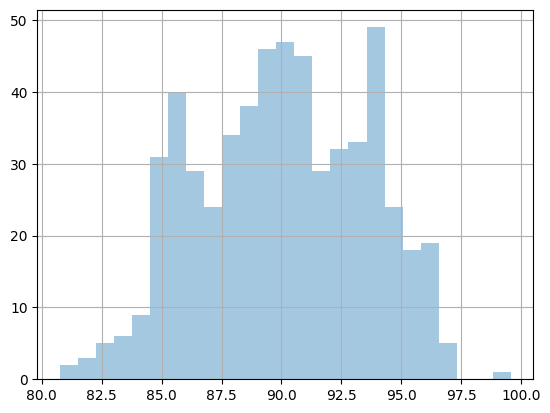

In [15]:
move_df = df[df['move_count']> 0 ]

move_df['counts_per_cm'] = move_df['move_count']/(move_df['distance_traveled']*100)


move_df['counts_per_cm'][1:].hist(bins = 25, label = str(count), alpha = 0.4)

In [17]:
move_df['counts_per_cm'][1:].mean()

90.0186645080008

In [18]:
import numpy as np

def calculate_turn_angles(df):
    """
    Calculate the angle formed by vectors originating at the current row
    (for rows with 'TURN:-1250' in the 'last_cmd' column) and spanning to the
    x-y locations 2 rows back and 1 row forward.
    """
    # Ensure the DataFrame is sorted by position or time
    df = df.reset_index(drop=True)

    # Initialize a column for the calculated angles
    df['turn_angle'] = np.nan

    for i in range(2, len(df) - 1):
        if 'TURN'  in df.loc[i, 'last_cmd']:
            # Coordinates for the current row
            x_curr, y_curr = df.loc[i, ['x', 'y']]

            # Coordinates 2 rows back
            x_back_2, y_back_2 = df.loc[i - 2, ['x', 'y']]

           # Coordinates 2 rows back
            x_back_1, y_back_1 = df.loc[i - 1, ['x', 'y']]


            # Coordinates 1 row forward
            x_forward, y_forward = df.loc[i + 1, ['x', 'y']]

            # Vectors originating from the current row
            vector_back = np.array([x_back_1 - x_back_2, y_back_1 - y_back_2])
            vector_forward = np.array([x_forward - x_curr, y_forward - y_curr])

            # Normalize the vectors
            norm_back = np.linalg.norm(vector_back)
            norm_forward = np.linalg.norm(vector_forward)

            if norm_back > 0 and norm_forward > 0:
                vector_back = vector_back / norm_back
                vector_forward = vector_forward / norm_forward

                # Calculate the angle using the dot product
                dot_product = np.clip(np.dot(vector_back, vector_forward), -1.0, 1.0)
                angle = np.arccos(dot_product)  # Angle in radians

                # Convert to degrees and store in the DataFrame
                df.loc[i, 'turn_angle'] = np.degrees(angle)

    return df

# Apply the function to the DataFrame
df = calculate_turn_angles(df)

# Display the rows with calculated turn angles
# df[['turn_angle']].dropna().mean()


In [20]:
df

,vive_data,last_cmd,yaw,pitch,roll,x,y,z,distance_traveled,move_count,turn_count,turn_angle
0,[-3.88309313e-02 1.00020178e-01 4.98039100e-...,MOVE:938.0108722915079,178.898884,-138.348586,-89.622811,-0.038831,0.100020,0.049804,1.047071,938,0,NaN
1,[-3.99389796e-02 1.02925663e-01 5.02188948e-...,TURN:312,178.771730,-114.426258,-90.880997,-0.039939,0.102926,0.050219,0.003110,0,312,NaN
2,[ 2.03657078e-03 2.01821312e-01 5.30848507e-...,MOVE:938.0108722915079,178.301643,-113.587477,-91.312851,0.002037,0.201821,0.053085,0.107435,938,0,NaN
3,[ 4.94028644e-03 2.01378469e-01 5.33709104e-...,TURN:-290,178.955547,-136.038485,-90.047595,0.004940,0.201378,0.053371,0.002937,0,-290,21.672735
4,[ 7.32366222e-03 3.04366815e-01 5.32804722e-...,MOVE:938.0108722915079,179.149274,-136.937567,-89.630904,0.007324,0.304367,0.053280,0.103016,938,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
758,[ 3.04907827e-01 1.07170861e-02 6.79262833e-...,MOVE:938.0108722915079,179.513901,124.028763,-88.368032,0.304908,0.010717,0.067926,0.100765,938,0,NaN
759,[ 2.05593556e-01 -1.47067326e-03 6.51906600e-...,MOVE:938.0108722915079,179.764605,123.899964,-88.452024,0.205594,-0.001471,0.065191,0.100059,938,0,NaN
760,[ 2.04897124e-01 -1.94175376e-03 6.50914798e-...,TURN:97,-107.976704,131.005470,-88.677349,0.204897,-0.001942,0.065091,0.000841,0,97,6.450019
761,[ 1.02189265e-01 -2.92105253e-03 6.05021608e-...,MOVE:938.0108722915079,-179.200866,133.181410,-87.949758,0.102189,-0.002921,0.060502,0.102713,938,0,NaN


/var/folders/j0/3mr_0p157c9d4qgnmrzwc8nm0000gn/T/ipykernel_2286/1831796383.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  turn_df['counts_per_degree'] = turn_df['turn_count'].abs()/turn_df['turn_angle'].abs()


<Axes: >

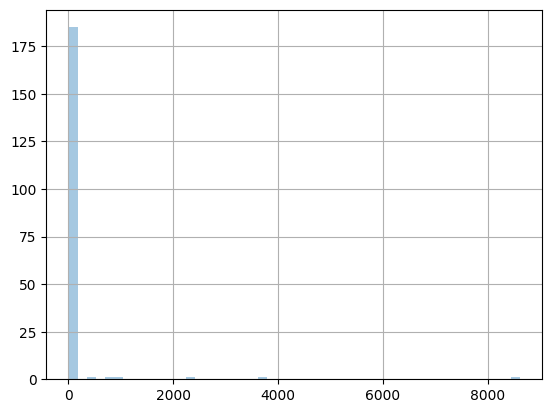

In [19]:
turn_df = df[df['turn_count'].abs()> 0 ]
turn_df['counts_per_degree'] = turn_df['turn_count'].abs()/turn_df['turn_angle'].abs()


turn_df['counts_per_degree'].hist(bins = 50, label = str(count), alpha = 0.4)



<Axes: >

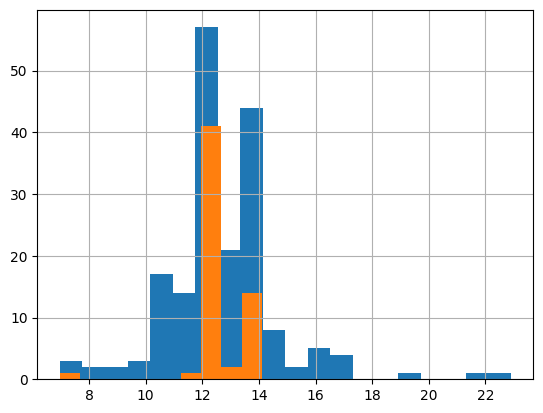

In [35]:
turn_df[turn_df['counts_per_degree'] < 50]['counts_per_degree'].hist(bins = 20)
turn_df[(turn_df['counts_per_degree'] < 50)&(turn_df['turn_angle']>80)]['counts_per_degree'].hist()


In [22]:
# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

# Print the DataFrame
df

# # Reset to default behavior if needed
# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_columns')

,vive_data,last_cmd,yaw,pitch,roll,x,y,z,distance_traveled,move_count,turn_count,turn_angle
0,[-3.88309313e-02 1.00020178e-01 4.98039100e-...,MOVE:938.0108722915079,178.898884,-138.348586,-89.622811,-0.038831,0.100020,0.049804,1.047071,938,0,NaN
1,[-3.99389796e-02 1.02925663e-01 5.02188948e-...,TURN:312,178.771730,-114.426258,-90.880997,-0.039939,0.102926,0.050219,0.003110,0,312,NaN
2,[ 2.03657078e-03 2.01821312e-01 5.30848507e-...,MOVE:938.0108722915079,178.301643,-113.587477,-91.312851,0.002037,0.201821,0.053085,0.107435,938,0,NaN
3,[ 4.94028644e-03 2.01378469e-01 5.33709104e-...,TURN:-290,178.955547,-136.038485,-90.047595,0.004940,0.201378,0.053371,0.002937,0,-290,21.672735
4,[ 7.32366222e-03 3.04366815e-01 5.32804722e-...,MOVE:938.0108722915079,179.149274,-136.937567,-89.630904,0.007324,0.304367,0.053280,0.103016,938,0,NaN
5,[ 7.98131253e-03 4.10499360e-01 5.32881976e-...,MOVE:938.0108722915079,179.181315,-137.567959,-89.225224,0.007981,0.410499,0.053288,0.106135,938,0,NaN
6,[ 9.13999368e-03 5.13592839e-01 5.44845769e-...,MOVE:938.0108722915079,179.050978,-137.062781,-90.012579,0.009140,0.513593,0.054485,0.103100,938,0,NaN
7,[ 1.02044177e-02 6.15951292e-01 5.46465960e-...,MOVE:938.0108722915079,178.863373,-137.385556,-89.915483,0.010204,0.615951,0.054647,0.102364,938,0,NaN
8,[ 1.18462117e-02 7.20842808e-01 5.52757302e-...,MOVE:938.0108722915079,178.755101,-136.828292,-90.123820,0.011846,0.720843,0.055276,0.104904,938,0,NaN
9,[ 1.32859710e-02 8.24938767e-01 5.50100202e-...,MOVE:938.0108722915079,178.038992,-137.735257,-90.433232,0.013286,0.824939,0.055010,0.104106,938,0,NaN


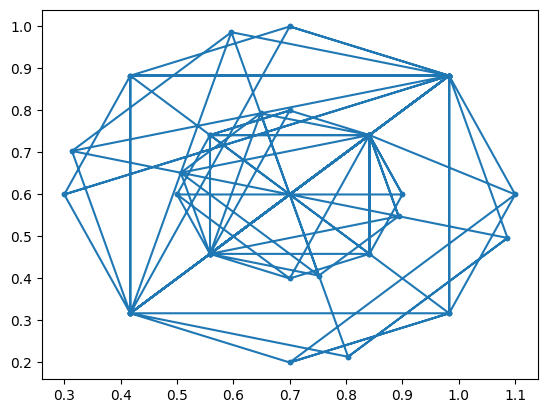